## Model 2 Random Forest

Based on evidence from the consulted studies, tree-based ensemble models such as  Random Forest seem the most suitable choice for intrusion detection using the NSL-KDD dataset. RF consistently achieved accuracy above 99% across multiple experiments. Main goal is to:
* Identify the most informative NSL-KDD features
* Improve multi-class prediction performance over logistic regression
* Build a more expressive model without overfitting
* Evaluate Model 2, generate interpretable insights to produce a final, optimized RF model ready for test evaluation

Furthermore, in Model 2, the RF algorithm is intentionally used twice, but for two different purposes. First, an initial RF is trained on the full feature set to compute feature importances. This model is not used for prediction, it is only used to rank the NSL-KDD attributes and identify which features carry meaningful signal versus which ones introduce noise or redundancy. Based on this ranking, a reduced subset of the most informative features is selected. In the second stage, a new RF model is trained and only on the selected features, to serve as the actual predictive classifier. This separation ensures that the final model benefits from a cleaner and lower-dimensional feature space and enables an assessment of how feature selection influences model performance.



#### Packages & Data

In [1]:
# Start by importing all required libs...
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from utils import load_split, FEATURE_COLUMNS, make_binary_labels
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, precision_recall_curve, roc_auc_score
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')

In [ ]:
# Part one: selecting the most important transformed features (one-hot space)
DATA_DIR   = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print("The shapes:")
print("  X_train:", X_train.shape)
print("  X_val:  ", X_val.shape)
print("  X_test: ", X_test.shape)

# Load fitted preprocessor to retrieve expanded feature names
preprocessor = joblib.load(DATA_DIR / "preprocessor.joblib")
FEATURE_NAMES = preprocessor.get_feature_names_out()

assert X_train.shape[1] == len(FEATURE_NAMES), "Feature dimension issue!"
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Split feature mismatch!"

# RF used only for ranking features
rf_feat_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_feat_imp.fit(X_train, y_train)

importances = rf_feat_imp.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": FEATURE_NAMES, "importance": importances})
    .sort_values("importance", ascending=False)
)

print("\nTop 10 transformed features by RF importance:")
print(feat_imp_df.head(10))

TOP_F = 20
top_features = feat_imp_df.head(TOP_F)["feature"].tolist()
print(f"\nSelected top-{TOP_F} transformed features:\n", top_features)

# index mapping in transformed feature space
name_to_idx = {name: idx for idx, name in enumerate(FEATURE_NAMES)}
selected_idx = [name_to_idx[f] for f in top_features]

X_train_sel = X_train[:, selected_idx]
X_val_sel   = X_val[:,   selected_idx]
X_test_sel  = X_test[:,  selected_idx]

print("\nThe shapes after feature selection:")
print("  X_train_sel:", X_train_sel.shape)
print("  X_val_sel:  ", X_val_sel.shape)
print("  X_test_sel: ", X_test_sel.shape)


The shapes:
  X_train: (100778, 122)
  X_val:   (25195, 122)
  X_test:  (22544, 122)

Top 10 transformed features by RF importance:
                             feature  importance
1                     num__src_bytes    0.096600
29           num__dst_host_srv_count    0.075378
2                     num__dst_bytes    0.056284
8                     num__logged_in    0.042290
31       num__dst_host_diff_srv_rate    0.038389
20                    num__srv_count    0.036668
32  num__dst_host_same_src_port_rate    0.033565
19                        num__count    0.032778
34         num__dst_host_serror_rate    0.030687
28               num__dst_host_count    0.029714

Selected top-20 transformed features:
 ['num__src_bytes', 'num__dst_host_srv_count', 'num__dst_bytes', 'num__logged_in', 'num__dst_host_diff_srv_rate', 'num__srv_count', 'num__dst_host_same_src_port_rate', 'num__count', 'num__dst_host_serror_rate', 'num__dst_host_count', 'num__dst_host_srv_serror_rate', 'num__duration', 'cat__

#### Multi-Class

In [ ]:
# Create a baseline RF
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_full.fit(X_train, y_train)

y_val_pred_full = rf_full.predict(X_val)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

print("Random Forest: all features")
print(classification_report(y_val, y_val_pred_full, digits=4)) # use 4 digits for more precise comparison?
print("Accuracy:", accuracy_score(y_val, y_val_pred_full))

# Evaluate full-feature model on the test set
y_test_pred_full = rf_full.predict(X_test)

print("Random Forest: all features (test set)")
print(classification_report(y_test, y_test_pred_full, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_full))


Random Forest: all features
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998      9186
           1     0.9982    0.9997    0.9990     13469
           2     0.9996    0.9944    0.9970      2331
           3     1.0000    0.9598    0.9795       199
           4     0.8889    0.8000    0.8421        10

    accuracy                         0.9989     25195
   macro avg     0.9773    0.9508    0.9635     25195
weighted avg     0.9989    0.9989    0.9989     25195

Accuracy: 0.9988886683865846
Random Forest: all features (test set)
              precision    recall  f1-score   support

           0     0.9612    0.7683    0.8540      7458
           1     0.6343    0.9741    0.7683      9711
           2     0.8648    0.5914    0.7025      2423
           3     0.8000    0.0028    0.0055      2885
           4     0.5000    0.0299    0.0563        67

    accuracy                         0.7378     22544
   macro avg     0.7521    0.4733  

During evaluation, scikit-learn generated ‘UndefinedMetricWarning’ for U2R and R2L classes. This occurs when the model predicts zero samples for a class, causing precision or F1-score to be undefined. This is typical for the NSL-KDD dataset, where some classes are extremely underrepresented.

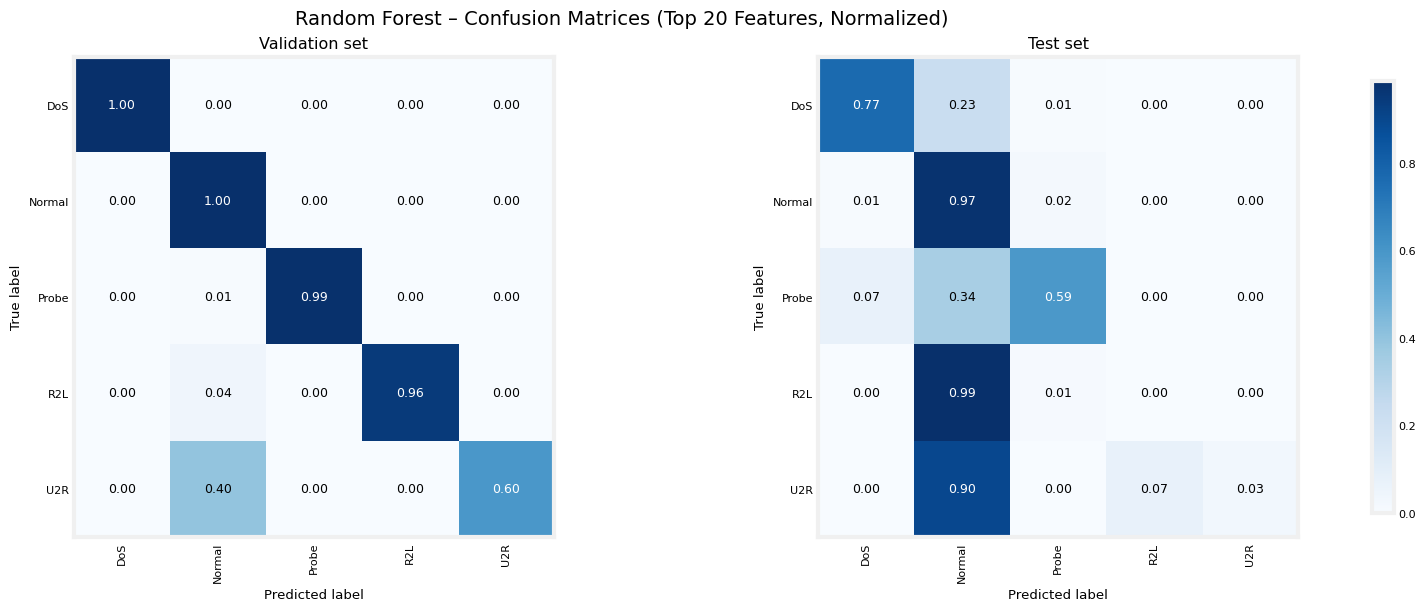

Random Forest: top 20 features
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9996      9186
           1     0.9976    0.9994    0.9985     13469
           2     0.9983    0.9927    0.9955      2331
           3     1.0000    0.9598    0.9795       199
           4     0.8571    0.6000    0.7059        10

    accuracy                         0.9984     25195
   macro avg     0.9705    0.9103    0.9358     25195
weighted avg     0.9984    0.9984    0.9984     25195

Accuracy: 0.9983726929946418
Random Forest: top 20 features (test set)
              precision    recall  f1-score   support

           0     0.9602    0.7663    0.8523      7458
           1     0.6350    0.9724    0.7683      9711
           2     0.8375    0.5894    0.6919      2423
           3     0.5455    0.0021    0.0041      2885
           4     0.4000    0.0299    0.0556        67

    accuracy                         0.7361     22544
   macro avg     0.6756    0.

In [5]:
# RF with feature selection
rf_feat = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_feat.fit(X_train_sel, y_train)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

y_val_pred_sel = rf_feat.predict(X_val_sel)
y_test_pred_sel = rf_feat.predict(X_test_sel)


label_map = {
    "normal": "Normal",
    "dos": "DoS",
    "probe": "Probe",
    "r2l": "R2L",
    "u2r": "U2R",
}

# Load encoder and map to display names
y_encoder = joblib.load("data/processed/label_encoder.joblib")
class_names = [label_map[c] for c in y_encoder.classes_]
class_ids = np.arange(len(class_names))

# Row-normalized confusion matrices
cm_val = confusion_matrix(
    y_val, y_val_pred_sel,
    labels=class_ids,
    normalize="true"
)

cm_test = confusion_matrix(
    y_test, y_test_pred_sel,
    labels=class_ids,
    normalize="true"
)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for ax, cm, title in zip(
    axes,
    (cm_val, cm_test),
    ("Validation set", "Test set")
):
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)

    ax.set_xticks(class_ids)
    ax.set_yticks(class_ids)
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

# Shared colorbar
fig.colorbar(im, ax=axes, shrink=0.9)
fig.suptitle(
    "Random Forest – Confusion Matrices (Top 20 Features, Normalized)",
    fontsize=14
)

plt.show()


print("Random Forest: top 20 features")
print(classification_report(y_val, y_val_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_val, y_val_pred_sel))

# Evaluate selected-feature model on the test set
y_test_pred_sel = rf_feat.predict(X_test_sel)

print("Random Forest: top 20 features (test set)")
print(classification_report(y_test, y_test_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_sel))

#### Binary

Normal class:  1
Binary RF (Validation) – Top 20 features
              precision    recall  f1-score   support

           0     0.9978    0.9992    0.9985     13469
           1     0.9991    0.9975    0.9983     11726

    accuracy                         0.9984     25195
   macro avg     0.9985    0.9984    0.9984     25195
weighted avg     0.9984    0.9984    0.9984     25195

Accuracy: 0.9984123834094066
Binary RF (Test) – Top 20 features
              precision    recall  f1-score   support

           0     0.6391    0.9724    0.7713      9711
           1     0.9655    0.5845    0.7282     12833

    accuracy                         0.7516     22544
   macro avg     0.8023    0.7785    0.7497     22544
weighted avg     0.8249    0.7516    0.7468     22544

Accuracy: 0.751596877217885


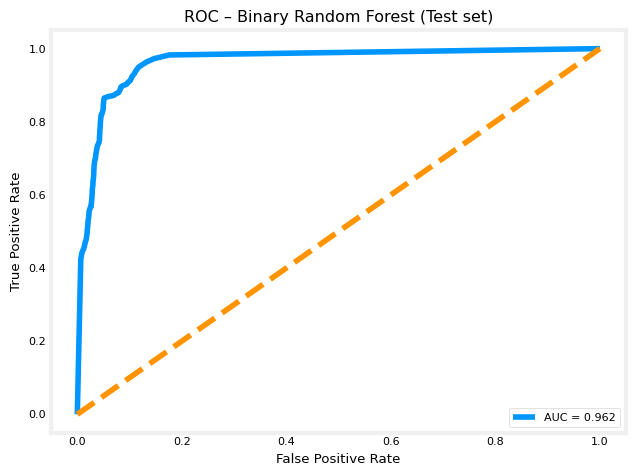

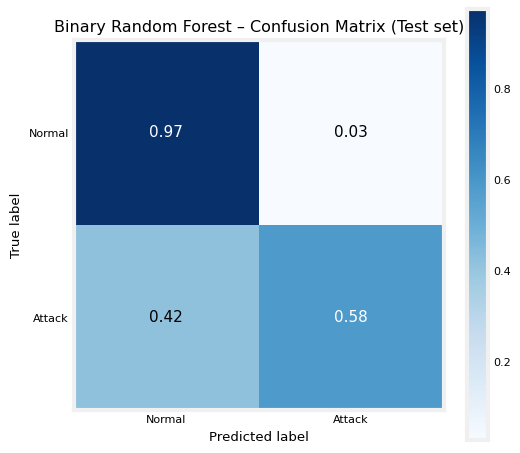

In [ ]:
# Extract normal class and convert to binary labels
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)


y_train_bin = make_binary_labels(y_train, normal_id)
y_val_bin   = make_binary_labels(y_val,   normal_id)
y_test_bin  = make_binary_labels(y_test,  normal_id)

# train and evaluate the binary model
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

rf_bin = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train_sel, y_train_bin)

y_val_bin_pred = rf_bin.predict(X_val_sel)
print("Binary RF (Validation) – Top 20 features")
print(classification_report(y_val_bin, y_val_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_val_bin, y_val_bin_pred))

y_test_bin_pred = rf_bin.predict(X_test_sel)
print("Binary RF (Test) – Top 20 features")
print(classification_report(y_test_bin, y_test_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_test_bin, y_test_bin_pred))


# ROC

y_test_scores = rf_bin.predict_proba(X_test_sel)[:, 1]

fpr, tpr, _ = roc_curve(y_test_bin, y_test_scores)
auc = roc_auc_score(y_test_bin, y_test_scores)

plt.figure(figsize=(6.4, 4.8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – Binary Random Forest (Test set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend([f"AUC = {auc:.3f}"], loc="lower right")
plt.tight_layout()
plt.show()

# confusion matrix
cm_bin = confusion_matrix(
    y_test_bin,
    y_test_bin_pred,
    normalize="true"
)

labels = ["Normal", "Attack"]

plt.figure(figsize=(5.5, 4.8))
plt.imshow(cm_bin, interpolation="nearest", cmap="Blues")
plt.title("Binary Random Forest – Confusion Matrix (Test set)")
plt.colorbar()

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Add values inside cells
thresh = cm_bin.max() / 2
for i in range(cm_bin.shape[0]):
    for j in range(cm_bin.shape[1]):
        plt.text(
            j, i,
            f"{cm_bin[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_bin[i, j] > thresh else "black",
            fontsize=11
        )

plt.tight_layout()
plt.show()